In [ ]:
# Capstone Project 3 
# Smart Marketing Prediction System (ML Pipeline Project)
# Scenario
# A fast-growing e-commerce company called ShopEasy is struggling with inefficient marketing campaigns.

# Every day thousands of users visit their website. The marketing team spends a large amount of money showing ads, discounts, and promotional emails, but they don't know which customers are actually likely to buy something.

# Currently:

# Many customers browse but never purchase

# Marketing money is wasted on the wrong users

# The company wants to predict purchase probability

# The data science team has been asked to build a machine learning system that predicts whether a customer will purchase a product during a session.

# If the system predicts high probability of purchase, the system will:

# show personalized product recommendations

# offer targeted discounts

# prioritize marketing campaigns

# If the system predicts low probability, the company will avoid spending marketing resources.

# However, the dataset contains both numerical and categorical features, so the data science team must design a complete ML pipeline.

# Dataset is available in DatasetCapstoneProject3 in the github repo link https://github.com/himanshusar123/Datasets

# Business Objective
# Build a machine learning model that predicts whether a user will purchase (1) or not purchase (0) during a website session.

# The model must be implemented using scikit-learn pipelines, including:

# Encoding techniques

# Feature preprocessing

# Model training

# Model selection

# Hyperparameter tuning




# Dataset is available in DatasetCapstoneProject4 in the github repo link https://github.com/himanshusar123/Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     cross_val_score, StratifiedKFold,
                                     LeaveOneOut)
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve)

import sklearn; print(f"   scikit-learn {sklearn.__version__}")


   scikit-learn 1.8.0


In [3]:
df = pd.read_excel('DatasetCapstoneProject3.xlsx')

print("SHOPEASY DATASET")
print(f"  Rows × Cols : {df.shape}")
print(f"  Target      : 'Purchased'  (1=Buy, 0=No Buy)")
print()
display(df)


SHOPEASY DATASET
  Rows × Cols : (15, 10)
  Target      : 'Purchased'  (1=Buy, 0=No Buy)



,CustomerID,Age,Gender,Device,Traffic_Source,Time_on_Website,Pages_Visited,Ad_Clicks,Previous_Purchases,Purchased
0,1,23,Male,Mobile,Social Media,5,3,1,0,0
1,2,35,Female,Desktop,Search Engine,12,8,3,2,1
2,3,29,Male,Tablet,Social Media,8,5,2,1,0
3,4,41,Female,Mobile,Email Campaign,15,10,4,3,1
4,5,22,Female,Desktop,Direct,4,2,0,0,0
5,6,38,Male,Desktop,Search Engine,18,11,5,4,1
6,7,30,Male,Mobile,Social Media,7,4,1,1,0
7,8,27,Female,Tablet,Email Campaign,9,6,2,2,1
8,9,45,Male,Desktop,Direct,20,12,5,5,1
9,10,24,Female,Mobile,Social Media,6,3,1,0,0


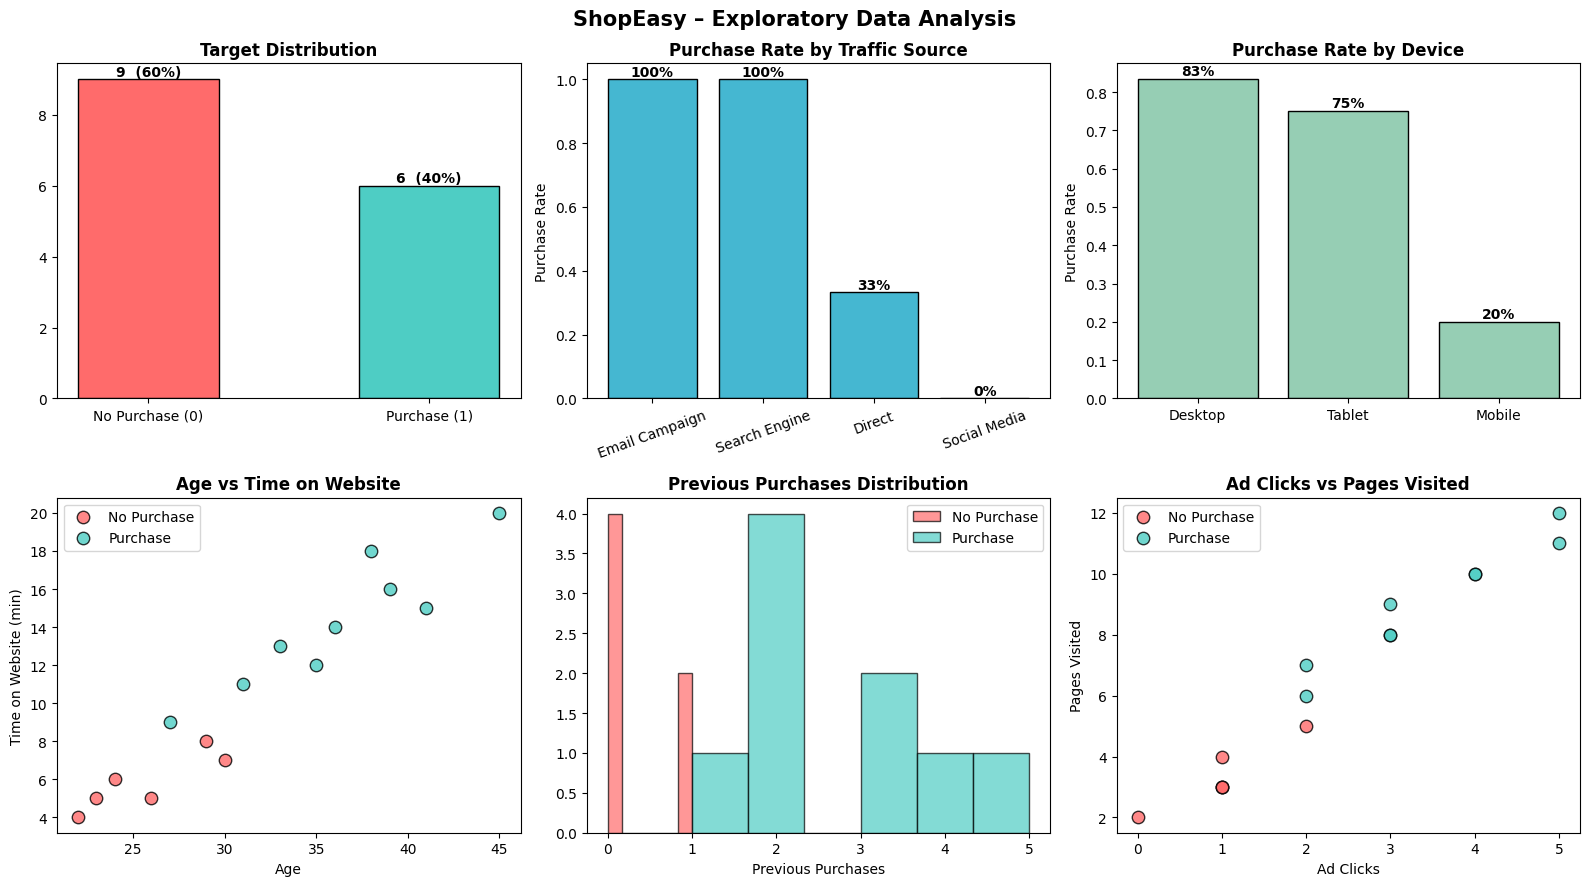

EDA complete


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('ShopEasy – Exploratory Data Analysis', fontsize=15, fontweight='bold')


counts = df['Purchased'].value_counts()
axes[0,0].bar(['No Purchase (0)', 'Purchase (1)'], counts.values,
               color=['#FF6B6B','#4ECDC4'], edgecolor='black', width=0.5)
axes[0,0].set_title('Target Distribution', fontweight='bold')
for i,v in enumerate(counts.values):
    axes[0,0].text(i, v+0.1, f'{v}  ({v/len(df):.0%})', ha='center', fontweight='bold')


ts = df.groupby('Traffic_Source')['Purchased'].mean().sort_values(ascending=False)
axes[0,1].bar(ts.index, ts.values, color='#45B7D1', edgecolor='black')
axes[0,1].set_title('Purchase Rate by Traffic Source', fontweight='bold')
axes[0,1].set_ylabel('Purchase Rate')
axes[0,1].tick_params(axis='x', rotation=20)
for i,(k,v) in enumerate(ts.items()):
    axes[0,1].text(i, v+0.01, f'{v:.0%}', ha='center', fontweight='bold', fontsize=10)

dev = df.groupby('Device')['Purchased'].mean().sort_values(ascending=False)
axes[0,2].bar(dev.index, dev.values, color='#96CEB4', edgecolor='black')
axes[0,2].set_title('Purchase Rate by Device', fontweight='bold')
axes[0,2].set_ylabel('Purchase Rate')
for i,(k,v) in enumerate(dev.items()):
    axes[0,2].text(i, v+0.01, f'{v:.0%}', ha='center', fontweight='bold', fontsize=10)


colors_map = {0:'#FF6B6B', 1:'#4ECDC4'}
for label in [0,1]:
    mask = df['Purchased']==label
    axes[1,0].scatter(df[mask]['Age'], df[mask]['Time_on_Website'],
                      c=colors_map[label], label='Purchase' if label else 'No Purchase',
                      edgecolors='black', s=80, alpha=0.8)
axes[1,0].set_xlabel('Age'); axes[1,0].set_ylabel('Time on Website (min)')
axes[1,0].set_title('Age vs Time on Website', fontweight='bold')
axes[1,0].legend()


for label, color, name in [(0,'#FF6B6B','No Purchase'),(1,'#4ECDC4','Purchase')]:
    axes[1,1].hist(df[df['Purchased']==label]['Previous_Purchases'],
                   bins=6, alpha=0.7, color=color, label=name, edgecolor='black')
axes[1,1].set_title('Previous Purchases Distribution', fontweight='bold')
axes[1,1].set_xlabel('Previous Purchases'); axes[1,1].legend()


for label in [0,1]:
    mask = df['Purchased']==label
    axes[1,2].scatter(df[mask]['Ad_Clicks'], df[mask]['Pages_Visited'],
                      c=colors_map[label], label='Purchase' if label else 'No Purchase',
                      edgecolors='black', s=80, alpha=0.8)
axes[1,2].set_xlabel('Ad Clicks'); axes[1,2].set_ylabel('Pages Visited')
axes[1,2].set_title('Ad Clicks vs Pages Visited', fontweight='bold')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('eda_shopeasy.png', dpi=130, bbox_inches='tight')
plt.show()
print("EDA complete")


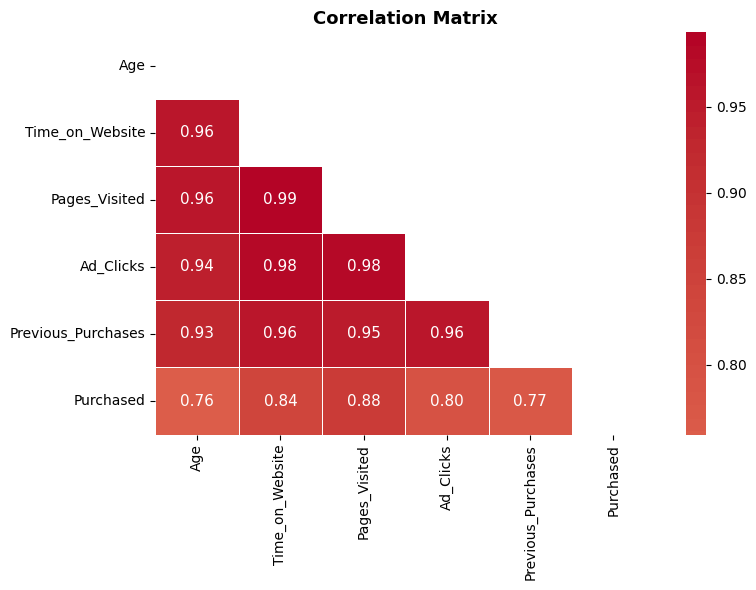

Key insight: Features most correlated with 'Purchased':
  Pages_Visited          +0.875  █████████████████
  Time_on_Website        +0.839  ████████████████
  Ad_Clicks              +0.799  ███████████████
  Previous_Purchases     +0.771  ███████████████
  Age                    +0.759  ███████████████


In [5]:
num_cols = ['Age','Time_on_Website','Pages_Visited','Ad_Clicks','Previous_Purchases','Purchased']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, linewidths=0.5,
            annot_kws={'size':11})
plt.title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation.png', dpi=130, bbox_inches='tight')
plt.show()

print("Key insight: Features most correlated with 'Purchased':")
corr_target = corr['Purchased'].drop('Purchased').sort_values(ascending=False)
for feat, val in corr_target.items():
    bar = '█' * int(abs(val) * 20)
    print(f"  {feat:<22} {val:+.3f}  {bar}")


In [6]:
TARGET = 'Purchased'
DROP   = ['CustomerID']

X = df.drop(columns=[TARGET] + DROP)
y = df[TARGET]

numerical_cols   = ['Age','Time_on_Website','Pages_Visited','Ad_Clicks','Previous_Purchases']
categorical_cols = ['Gender','Device','Traffic_Source']

print("Numerical   :", numerical_cols)
print("Categorical :", categorical_cols)
print(f"\nDataset size: {len(X)} rows  |  Target balance: {y.value_counts().to_dict()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train)} rows  |  Test: {len(X_test)} rows")
print("(Dataset is small — LOO-CV will also be used for robust evaluation)")


Numerical   : ['Age', 'Time_on_Website', 'Pages_Visited', 'Ad_Clicks', 'Previous_Purchases']
Categorical : ['Gender', 'Device', 'Traffic_Source']

Dataset size: 15 rows  |  Target balance: {1: 9, 0: 6}

Train: 12 rows  |  Test: 3 rows
(Dataset is small — LOO-CV will also be used for robust evaluation)


In [7]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline,   numerical_cols),
    ('cat', cat_pipeline,   categorical_cols)
])


pipelines = {
    'Logistic Regression': Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('pre', preprocessor),
        ('clf', DecisionTreeClassifier(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('pre', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('pre', preprocessor),
        ('clf', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
}

print("Pipelines created:")
for name in pipelines:
    print(f"   • {name}")


Pipelines created:
   • Logistic Regression
   • Decision Tree
   • Random Forest
   • Gradient Boosting


In [8]:
loo = LeaveOneOut()
results_loo  = {}
results_acc  = {}


print(f"{'Model':<22}  {'LOO Accuracy':>13}  {'Hold-out Acc':>13}")


for name, pipe in pipelines.items():
    loo_scores = cross_val_score(pipe, X, y, cv=loo, scoring='accuracy')
    results_loo[name] = loo_scores.mean()

    pipe.fit(X_train, y_train)
    hold_acc = accuracy_score(y_test, pipe.predict(X_test))
    results_acc[name] = hold_acc

    print(f"{name:<22}  {loo_scores.mean():>12.4f}   {hold_acc:>12.4f}")

best_name = max(results_loo, key=results_loo.get)
print(f"\nBest model (LOO CV): {best_name}  →  {results_loo[best_name]:.4f}")


Model                    LOO Accuracy   Hold-out Acc
Logistic Regression           1.0000         1.0000
Decision Tree                 0.9333         1.0000
Random Forest                 0.9333         1.0000
Gradient Boosting             0.9333         1.0000

Best model (LOO CV): Logistic Regression  →  1.0000


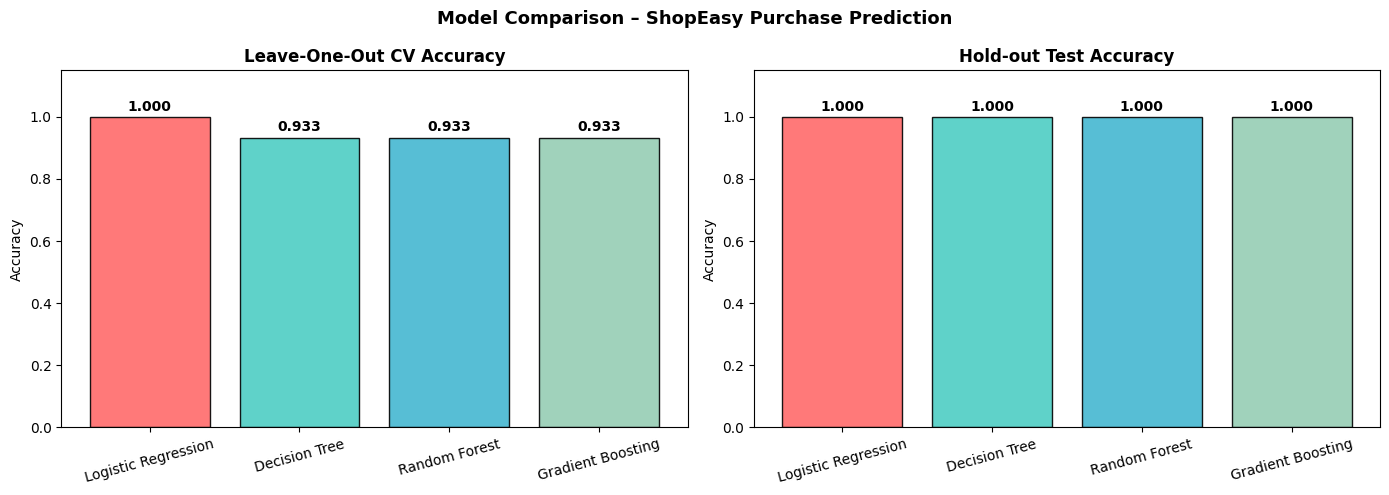

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison – ShopEasy Purchase Prediction', fontsize=13, fontweight='bold')

colors = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4']

bars1 = axes[0].bar(results_loo.keys(), results_loo.values(),
                    color=colors, edgecolor='black', alpha=0.9)
axes[0].set_title('Leave-One-Out CV Accuracy', fontweight='bold')
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=15)
for b, v in zip(bars1, results_loo.values()):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.3f}',
                 ha='center', fontweight='bold')


bars2 = axes[1].bar(results_acc.keys(), results_acc.values(),
                    color=colors, edgecolor='black', alpha=0.9)
axes[1].set_title('Hold-out Test Accuracy', fontweight='bold')
axes[1].set_ylim(0, 1.15); axes[1].set_ylabel('Accuracy')
axes[1].tick_params(axis='x', rotation=15)
for b, v in zip(bars2, results_acc.values()):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.3f}',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()


In [11]:
param_grid = {
    'clf__n_estimators':      [50, 100, 200],
    'clf__max_depth':         [None, 3, 5],
    'clf__min_samples_split': [2, 3],
    'clf__max_features':      ['sqrt', 'log2']
}

rf_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

grid_search = GridSearchCV(
    estimator  = rf_pipe,
    param_grid = param_grid,
    cv         = LeaveOneOut(),
    scoring    = 'accuracy',
    n_jobs     = -1,
    verbose    = 0
)

grid_search.fit(X, y)

print("HYPERPARAMETER TUNING – RANDOM FOREST")
print(f"Best LOO Accuracy : {grid_search.best_score_:.4f}")
print("Best Parameters   :")
for k, v in grid_search.best_params_.items():
    print(f"  {k:<35} {v}")


HYPERPARAMETER TUNING – RANDOM FOREST
Best LOO Accuracy : 0.9333
Best Parameters   :
  clf__max_depth                      None
  clf__max_features                   sqrt
  clf__min_samples_split              2
  clf__n_estimators                   50


In [12]:
best_pipe = grid_search.best_estimator_
best_pipe.fit(X_train, y_train)
y_pred  = best_pipe.predict(X_test)

try:
    y_proba = best_pipe.predict_proba(X_test)[:, 1]
    roc_auc  = roc_auc_score(y_test, y_proba)
    has_proba = True
except:
    has_proba = False

acc = accuracy_score(y_test, y_pred)

print("FINAL EVALUATION ON TEST SET")
print(f"  Accuracy : {acc:.4f}  ({acc*100:.1f}%)")
if has_proba:
    print(f"  ROC-AUC  : {roc_auc:.4f}")
print()
print(classification_report(y_test, y_pred,
      target_names=['No Purchase','Purchase']))


FINAL EVALUATION ON TEST SET
  Accuracy : 1.0000  (100.0%)
  ROC-AUC  : 1.0000

              precision    recall  f1-score   support

 No Purchase       1.00      1.00      1.00         1
    Purchase       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



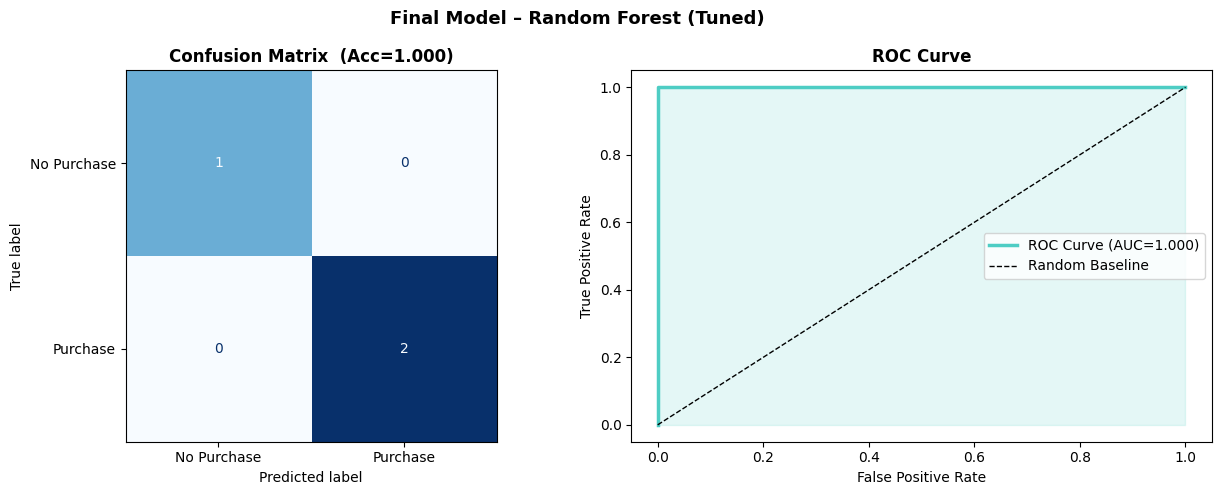

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Final Model – Random Forest (Tuned)', fontsize=13, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Purchase','Purchase']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix  (Acc={acc:.3f})', fontweight='bold')

if has_proba:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, color='#4ECDC4', lw=2.5,
                 label=f'ROC Curve (AUC={roc_auc:.3f})')
    axes[1].fill_between(fpr, tpr, alpha=0.15, color='#4ECDC4')
    axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random Baseline')
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve', fontweight='bold'); axes[1].legend()

plt.tight_layout()
plt.savefig('final_eval.png', dpi=130, bbox_inches='tight')
plt.show()


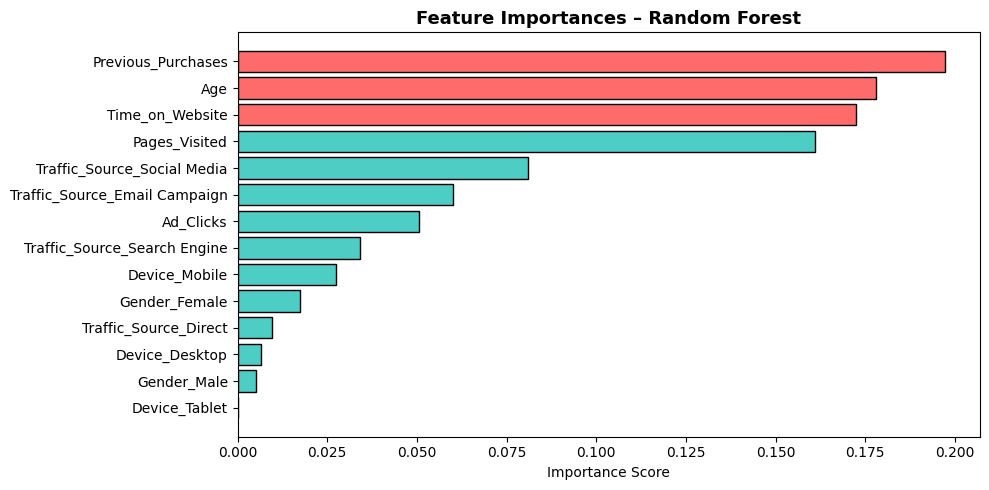

Top Features Driving Purchase Prediction:
  Previous_Purchases                  0.1971  ███████████████████
  Age                                 0.1780  █████████████████
  Time_on_Website                     0.1725  █████████████████
  Pages_Visited                       0.1609  ████████████████
  Traffic_Source_Social Media         0.0809  ████████


In [14]:
rf_clf  = best_pipe.named_steps['clf']
prep    = best_pipe.named_steps['pre']
cat_names = (prep.named_transformers_['cat']
             .named_steps['encoder']
             .get_feature_names_out(categorical_cols).tolist())
all_names = numerical_cols + cat_names

imp_df = pd.DataFrame({'Feature': all_names,
                       'Importance': rf_clf.feature_importances_})
imp_df = imp_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#FF6B6B' if i < 3 else '#4ECDC4' for i in range(len(imp_df))]
plt.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1],
         color=colors[::-1], edgecolor='black')
plt.title('Feature Importances – Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()

print("Top Features Driving Purchase Prediction:")
for _, row in imp_df.head(5).iterrows():
    bar = '█' * int(row['Importance']*100)
    print(f"  {row['Feature']:<35} {row['Importance']:.4f}  {bar}")


In [15]:

def predict_purchase(session: dict) -> dict:
    """
    Predict purchase probability for a single customer session.

    Parameters
    ----------
    session : dict  – keys must match feature columns (excluding CustomerID)

    Returns
    -------
    dict with prediction, probability, marketing tier and recommended action
    """
    df_in   = pd.DataFrame([session])
    pred    = best_pipe.predict(df_in)[0]
    proba   = best_pipe.predict_proba(df_in)[0][1]

    if proba >= 0.75:
        tier   = 'HIGH INTENT'
        action = 'Show personalized recommendations + flash discount'
    elif proba >= 0.45:
        tier   = 'MEDIUM INTENT'
        action = 'Send targeted email / retargeting ad'
    else:
        tier   = 'LOW INTENT'
        action = 'No spend — save marketing budget'

    return {
        'Will_Purchase':    bool(pred),
        'Probability':      f'{proba:.1%}',
        'Marketing_Tier':   tier,
        'Recommended_Action': action
    }




print("SHOPEASY REAL-TIME MARKETING ENGINE")


test_cases = [
    {'Age':39, 'Gender':'Female', 'Device':'Desktop',
     'Traffic_Source':'Search Engine', 'Time_on_Website':16,
     'Pages_Visited':10, 'Ad_Clicks':4, 'Previous_Purchases':3},
    {'Age':22, 'Gender':'Female', 'Device':'Mobile',
     'Traffic_Source':'Social Media', 'Time_on_Website':4,
     'Pages_Visited':2, 'Ad_Clicks':0, 'Previous_Purchases':0},
    {'Age':27, 'Gender':'Female', 'Device':'Tablet',
     'Traffic_Source':'Email Campaign', 'Time_on_Website':9,
     'Pages_Visited':6, 'Ad_Clicks':2, 'Previous_Purchases':2},
]

for i, session in enumerate(test_cases, 1):
    result = predict_purchase(session)
    print(f"\nCustomer #{i}  |  Age:{session['Age']}  Device:{session['Device']}  Source:{session['Traffic_Source']}")
    print(f"  Purchase Probability : {result['Probability']}")
    print(f"  Marketing Tier       : {result['Marketing_Tier']}")
    print(f"  Recommended Action   : {result['Recommended_Action']}")


SHOPEASY REAL-TIME MARKETING ENGINE

Customer #1  |  Age:39  Device:Desktop  Source:Search Engine
  Purchase Probability : 100.0%
  Marketing Tier       : HIGH INTENT
  Recommended Action   : Show personalized recommendations + flash discount

Customer #2  |  Age:22  Device:Mobile  Source:Social Media
  Purchase Probability : 2.0%
  Marketing Tier       : LOW INTENT
  Recommended Action   : No spend — save marketing budget

Customer #3  |  Age:27  Device:Tablet  Source:Email Campaign
  Purchase Probability : 92.0%
  Marketing Tier       : HIGH INTENT
  Recommended Action   : Show personalized recommendations + flash discount


In [16]:
X_all = df.drop(columns=['Purchased','CustomerID'])
y_all = df['Purchased']
proba_all = best_pipe.predict_proba(X_all)[:, 1]
pred_all  = best_pipe.predict(X_all)

summary = df[['CustomerID','Age','Device','Traffic_Source','Previous_Purchases','Purchased']].copy()
summary['Predicted_Probability'] = proba_all.round(3)
summary['Predicted_Purchase']    = pred_all
summary['Correct']               = (pred_all == y_all.values)
summary['Marketing_Tier']        = summary['Predicted_Probability'].apply(
    lambda p: 'HIGH' if p >= 0.75 else ('MEDIUM' if p >= 0.45 else 'LOW')
)


print(" FULL DATASET PREDICTIONS")
display(summary)

print("\nMarketing Budget Allocation:")
tier_counts = summary['Marketing_Tier'].value_counts()
for tier, cnt in tier_counts.items():
    print(f"  {tier:<8}: {cnt} customers")


 FULL DATASET PREDICTIONS


,CustomerID,Age,Device,Traffic_Source,Previous_Purchases,Purchased,Predicted_Probability,Predicted_Purchase,Correct,Marketing_Tier
0,1,23,Mobile,Social Media,0,0,0.00,0,True,LOW
1,2,35,Desktop,Search Engine,2,1,0.98,1,True,HIGH
2,3,29,Tablet,Social Media,1,0,0.20,0,True,LOW
3,4,41,Mobile,Email Campaign,3,1,0.98,1,True,HIGH
4,5,22,Desktop,Direct,0,0,0.10,0,True,LOW
5,6,38,Desktop,Search Engine,4,1,1.00,1,True,HIGH
6,7,30,Mobile,Social Media,1,0,0.10,0,True,LOW
7,8,27,Tablet,Email Campaign,2,1,0.92,1,True,HIGH
8,9,45,Desktop,Direct,5,1,0.92,1,True,HIGH
9,10,24,Mobile,Social Media,0,0,0.02,0,True,LOW



Marketing Budget Allocation:
  HIGH    : 9 customers
  LOW     : 6 customers
